m05_day05_langGraph-basic : copy

In [6]:
# poetry add langgraph
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

In [8]:
# 에이전트가 사용할 도구 정의
@tool
def recommend_recipe(dish: str):
    """ 주어진 요리에 대한 간단한 레시피를 제공합니다. """
    recipes = {
        "파스타": "재료: 스파게티 면, 토마토 소스, 올리브 오일, 마늘. 면을 삶고 소스를 부어주세요.",
        "불고기": "재료: 소고기, 간장, 설탕, 마늘. 고기를 양념에 재워 볶아주세요.",
        "샐러드": "재료: 양상추, 토마토, 오이, 드레싱. 채소를 썰어 드레싱과 버무려주세요."
    }
    # get(key) : key값이 없으면 보통 에러가 나지만 get은 에러가 나지 않게 None을 내보냄
    # dish = key -> 키에 해당하는 값이 없으면 '죄송하지만...' 출력
    return recipes.get(dish, '죄송하지만 해당 요리의 레시피를 찾을 수 없습니다.' ) 

# 도구 리스트에 추가
tools = [recommend_recipe]

# ToolNode 생성
tool_node = ToolNode(tools)

In [9]:
# 워크플로 그래프 생성 및 상태 관리

# 모델 GPT -> 도구 연결
model = ChatOpenAI(model='gpt-4o-mini', temperature=0).bind_tools(tools)

# 계속할지 여부를 결정하는 함수 정의
def should_continue(state: MessagesState):
    messages = state['messages']
    last_message = messages[-1] # 맨 끝을 뜻하는 -1
    # LLM이 도구 호출을 하면 'tools' 노드로
    if last_message.tool_calls:
        return 'tools'
    # 그렇지 않으면 중지(사용자에게 응답)
    return END

# 모델을 호출하는 함수 정의
def call_model(state: MessagesState):
    messages = state['messages']
    response = model.invoke(messages)
    # 기존 목록에 추가되기 때문에 목록을 반환한다
    return {'messages' : [response]}


In [10]:
# 새로운 그래프 정의
workflow = StateGraph(MessagesState)

# 노드 정의
workflow.add_node('agent', call_model) # agent가 call_model을 호출하도록
workflow.add_node('tools', tool_node) # tools(도구)는 tool_node

# 진입점을 'agent'로 설정 -> 첫번째로 호출되는 노드를 이미
workflow.set_entry_point('agent')

# 조건부 경로 추가
workflow.add_conditional_edges(
    'agent',  # 먼저, 시작 노드를 정의 -> 'agent' 노드가 호출된 후의 경로를 지정
    should_continue,  # 어느 노드가 다음에 호출될지 결정하는 함수 전달
)

# 'tools'에서 'agent'로의 일반 경로 추가 -> 'tools'가 호출된 후 'agent' 노드가 다음에 호출된다는 것을 의미
workflow.add_edge('tools', 'agent')

In [ ]:
# 그래프 실행 간 상태를 유지하기 위해 메모리 초기화
checkpointer = MemorySaver()

# 마지막으로 워크플로를 컴파일하여 실행 가능한 애플리케이션 app을 생성
# 이를 LangChain Runnable로 컴파일하여 다른 runnable처럼 사용할 수 있게 함
# 그래프를 컴파일할 때 메모리를 옵션 체크포인터로 전달할 수 있음
app = workflow.compile(checkpointer=checkpointer)

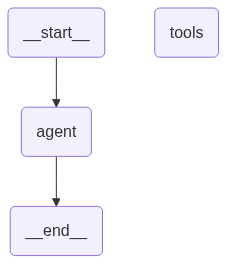

In [12]:
# 워크플로 그래프 시각화
from IPython.display import Image, display
# 예외처리
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# 랭그래프 기본 시작, 끝, 노드를 agent로
# start 다음 agent(첫번째로 호출되는 노드로 설정했기 때문)

In [16]:
# 에이전트와의 상호작용
final_state = app.invoke(
    {"messages": [HumanMessage(content="불고기 레시피 알려줄래?")]},
    config={"configurable": {"thread_id": 100}}
)
final_state["messages"][-1].content

'불고기 레시피는 다음과 같습니다:\n\n### 재료\n- 소고기\n- 간장\n- 설탕\n- 마늘\n\n### 조리 방법\n1. 소고기를 얇게 썰어주세요.\n2. 간장, 설탕, 다진 마늘을 섞어 양념을 만듭니다.\n3. 썰어놓은 소고기를 양념에 재워 30분 정도 둡니다.\n4. 팬에 기름을 두르고 재운 소고기를 볶아주세요.\n5. 고기가 익으면 접시에 담아 맛있게 즐기세요!\n\n맛있게 만들어 드세요!'

In [ ]:
# 동일한 "thread_id"를 사용하여 Runnable을 다시 호출
# 메모리체크포인터를 통해 상태가 유지되기 때문에 이전에 제공한 정보 기억
final_state = app.invoke(
    {"messages": [HumanMessage(content="방금 어떤 레시피를 알려주었지?")]},
    config={"configurable": {"thread_id": 100}}
)
final_state["messages"][-1].content

'방금 불고기 레시피를 알려드렸습니다. 소고기를 간장, 설탕, 마늘로 양념하여 볶는 간단한 요리 방법이었습니다.'

In [21]:
final_state['messages']

[HumanMessage(content='불고기 레시피 알려줄래?', additional_kwargs={}, response_metadata={}, id='4435a351-4351-4883-a466-23ee744af542'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_8uKkqpXFiFXTsCqW0uyjdtxW', 'function': {'arguments': '{"dish":"불고기"}', 'name': 'recommend_recipe'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 61, 'total_tokens': 78, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-C8m77tq4Vq6oHhjM2xrGYfBUW4qkC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--12379556-b6b1-45be-9df1-ceaea8b26b2b-0', tool_calls=[{'name': 'recommend_recipe', 'args': {'dish': '불고기'}, 'id': 'call_8uKkqpXFiFXTsCqW0uyjdtxW

In [ ]:
# 새로운 "thread_id"를 사용하여 Runnable을 호출
final_state = app.invoke(
    {"messages": [HumanMessage(content="방금 어떤 레시피를 알려주었지?")]},
    config={"configurable": {"thread_id": 500}}
)
final_state["messages"][-1].content

'아직 레시피를 제공하지 않았습니다. 어떤 요리에 대한 레시피를 원하시는지 말씀해 주시면, 그에 맞는 레시피를 추천해 드리겠습니다!'